In [1]:
import importlib
import pandas as pd
import sys
sys.path.append(r'../src/')
import utils.order_book.order_book_impl as book_utils
import utils.order_book.utils as utils
import utils.order_book.graphic_utils as graph_utils

In [2]:
importlib.reload(book_utils)
importlib.reload(utils)
importlib.reload(graph_utils)
Order_book = book_utils.Order_book()
Order_book._generate_n_random_order(100)

Generating order book: 100%|██████████| 100/100 [00:00<00:00, 433.27it/s]


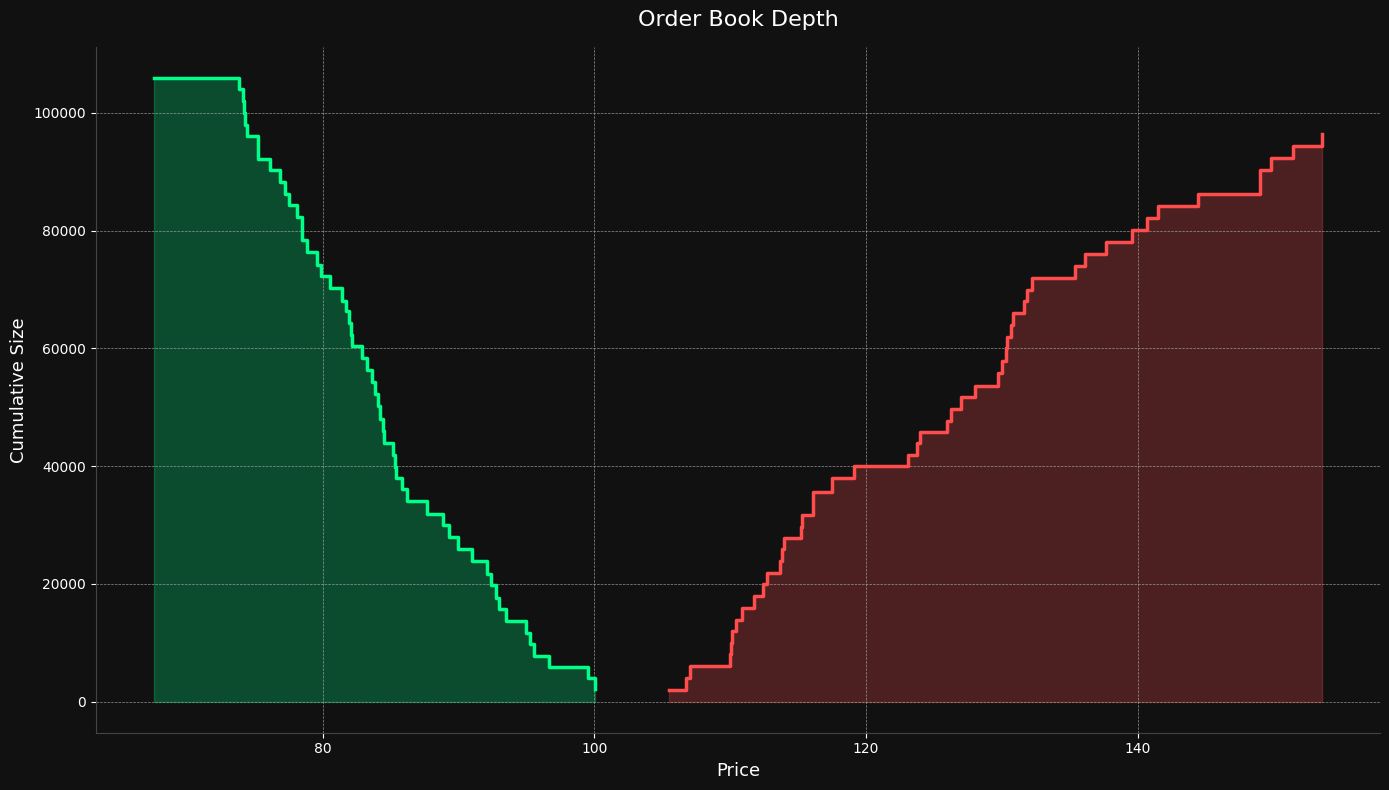

In [3]:
importlib.reload(book_utils)
graph_utils.plot_order_book(Order_book)

In [4]:
Order_book._df_bid_book

,Id,Price,Size,Type,Origin,Time
1776239981361_8218,1776239981361_8218,100.0235,2051,limit_order,market_maker,2026-04-15 09:59:41.361
1776239981366_2026,1776239981366_2026,92.7351,1960,limit_order,market_maker,2026-04-15 09:59:41.366
1776239981368_9358,1776239981368_9358,87.6898,1913,limit_order,market_maker,2026-04-15 09:59:41.368
1776239981375_8626,1776239981375_8626,88.8467,2004,limit_order,market_maker,2026-04-15 09:59:41.375
1776239981380_8229,1776239981380_8229,90.9741,2069,limit_order,market_maker,2026-04-15 09:59:41.380
1776239981386_3188,1776239981386_3188,93.4923,2075,limit_order,market_maker,2026-04-15 09:59:41.386
1776239981387_0129,1776239981387_0129,92.9691,1976,limit_order,market_maker,2026-04-15 09:59:41.387
1776239981389_7875,1776239981389_7875,85.7926,2008,limit_order,market_maker,2026-04-15 09:59:41.389
1776239981392_0763,1776239981392_0763,84.4898,2106,limit_order,market_maker,2026-04-15 09:59:41.392
1776239981394_4287,1776239981394_4287,84.4284,2070,limit_order,market_maker,2026-04-15 09:59:41.394


Generating order book: 100%|██████████| 40/40 [00:00<00:00, 420.85it/s]

MM book: 41 orders
  Bids: 18
  Asks: 23
  Best bid: 100.7229
  Best ask: 100.7230


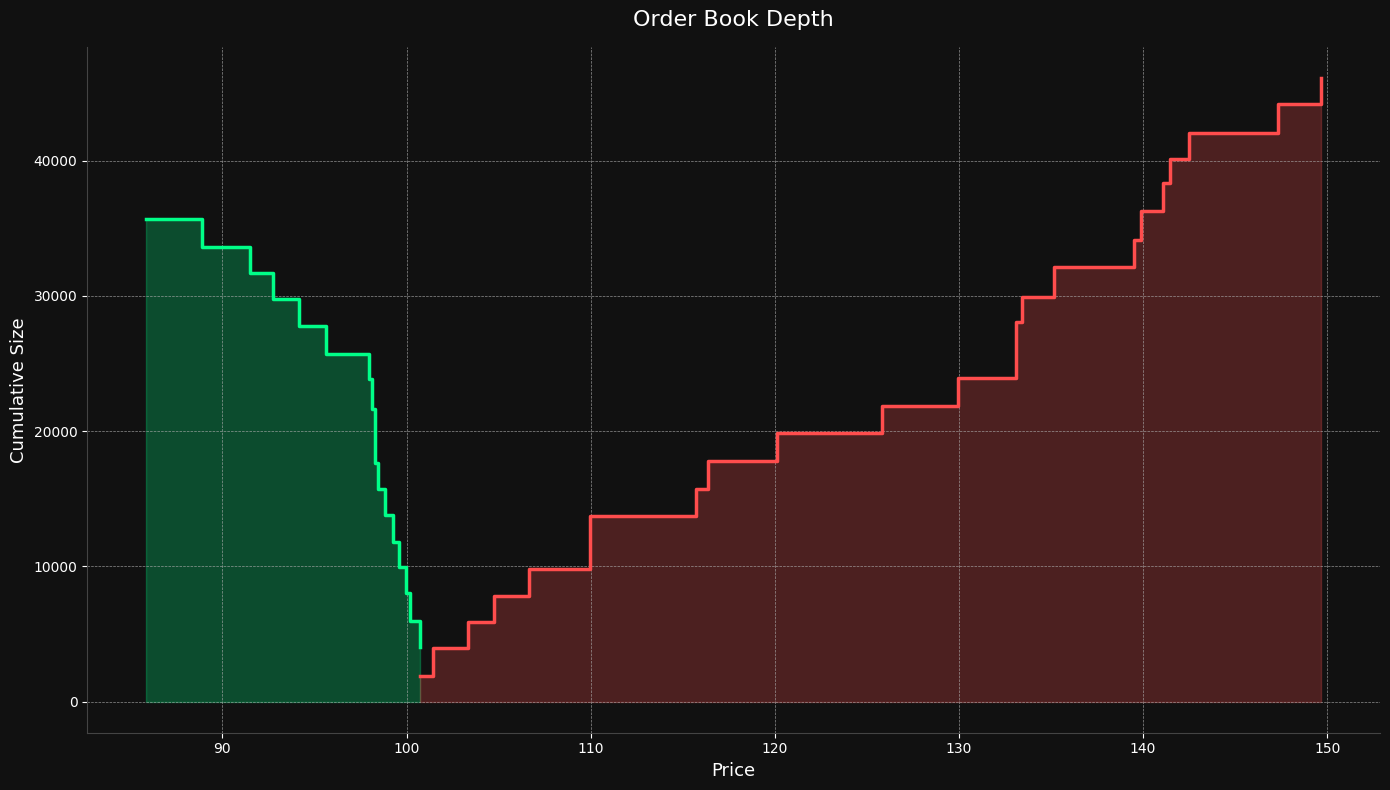

In [5]:
importlib.reload(book_utils)
importlib.reload(graph_utils)

ob = book_utils.Order_book()
ob._generate_n_random_order(40)

print(f"MM book: {len(ob._df_order_book)} orders")
print(f"  Bids: {(ob._df_order_book["Direction"]=="buy").sum()}")
print(f"  Asks: {(ob._df_order_book["Direction"]=="sell").sum()}")
print(f"  Best bid: {ob._df_order_book[ob._df_order_book["Direction"]=="buy"]["Price"].max():.4f}")
print(f"  Best ask: {ob._df_order_book[ob._df_order_book["Direction"]=="sell"]["Price"].min():.4f}")
graph_utils.plot_order_book(ob)

## Simulation

The market maker order book is now seeded. Key properties:
- All orders have `origin = "market_maker"`
- Bids and asks never cross (bid always < best ask)
- Prices generated via truncated normal distribution anchored on last price

Next steps:
1. **Generate client orders** with `generate_random_orders(n, origin="client")` — returns a list, does not touch the book
2. **Submit the batch** with `add_orders_batch(orders)` — adds to book then triggers clearing
3. **Inspect matches** in `ob._df_matches` — client vs MM orders, price-time priority, partial fills supported
4. **Cancel orders** to clean up the book after clearing

In [6]:
client_orders = ob.generate_random_orders(10, origin="client")
ob.add_orders_batch(client_orders)

Adding orders: 100%|██████████| 10/10 [00:00<00:00, 1751.28it/s]


In [7]:
ob._df_ask_book.sort_values("Price")

,Id,Price,Size,Type,Origin,Time
1776239981766_4354,1776239981766_4354,100.7230,1912,limit_order,market_maker,2026-04-15 09:59:41.766
1776239981768_6665,1776239981768_6665,101.4123,2061,limit_order,market_maker,2026-04-15 09:59:41.768
1776239981771_2142,1776239981771_2142,103.3403,1935,limit_order,market_maker,2026-04-15 09:59:41.771
1776239981762_6970,1776239981762_6970,104.7333,1931,limit_order,market_maker,2026-04-15 09:59:41.762
1776239981756_9153,1776239981756_9153,106.6534,2000,limit_order,market_maker,2026-04-15 09:59:41.756
1776239981772_7124,1776239981772_7124,109.9584,1830,limit_order,market_maker,2026-04-15 09:59:41.772
1776239981714_4618,1776239981714_4618,109.9665,2055,limit_order,market_maker,2026-04-15 09:59:41.714
1776239981717_8080,1776239981717_8080,115.7117,1994,limit_order,market_maker,2026-04-15 09:59:41.717
1776239981720_9419,1776239981720_9419,116.3621,2083,limit_order,market_maker,2026-04-15 09:59:41.720
1776239981773_2415,1776239981773_2415,120.1065,2024,limit_order,market_maker,2026-04-15 09:59:41.773


In [8]:
len(ob._df_ask_book)

31

In [9]:
client_orders = ob.generate_random_orders(10, origin="client")
ob.add_orders_batch(client_orders)

print(f"Matches: {len(ob._df_matches)}")
ob._df_matches[["Direction", "Price", "MatchedSize", "ClientOrderId", "MmOrderId"]]

Adding orders: 100%|██████████| 10/10 [00:00<00:00, 2050.50it/s]

Matches: 1


,Direction,Price,MatchedSize,ClientOrderId,MmOrderId
0,buy,100.723,1912,1776239981929_3156,1776239981766_4354


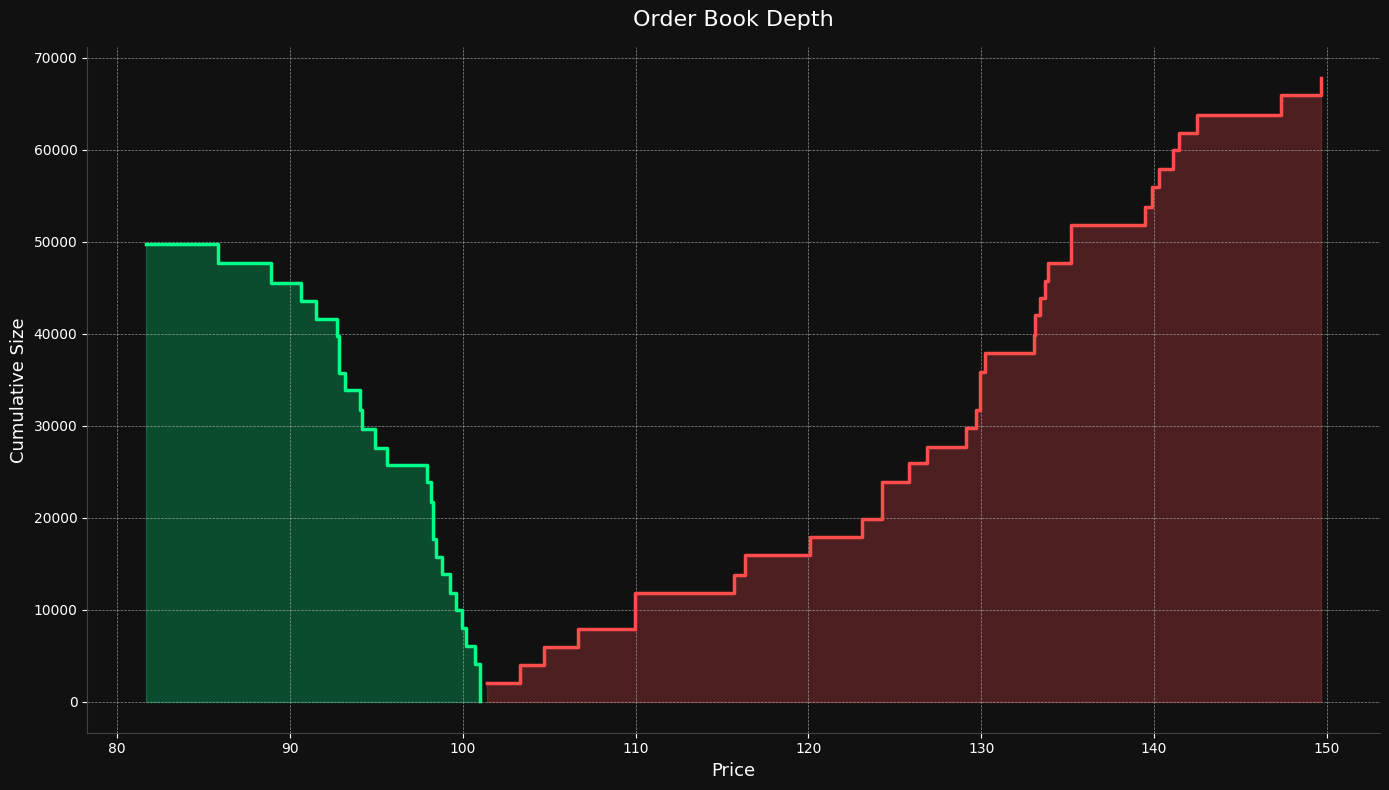

In [10]:
graph_utils.plot_order_book(ob)

In [11]:
if not ob._df_matches.empty:
    by_dir = ob._df_matches.groupby("Direction").agg(
        Matches=("MatchedSize", "count"),
        Volume=("MatchedSize", "sum"),
        AvgPrice=("Price", "mean"),
    )
    print(f"Total matched volume : {ob._df_matches['MatchedSize'].sum():,.0f}")
    print(f"Remaining open orders: {len(ob._df_order_book)}")
    print()
    print(by_dir)
else:
    print("No matches â€” client prices did not cross MM quotes (try re-running)")

Total matched volume : 1,912
Remaining open orders: 60

           Matches  Volume  AvgPrice
Direction                           
buy              1    1912   100.723


In [12]:
# cancel specific orders by ID
some_ids = ob._df_order_book.index[:3].tolist()
print(f"Before cancel_orders: {len(ob._df_order_book)} orders")
ob.cancel_orders(some_ids)
print(f"After cancel_orders({len(some_ids)} ids): {len(ob._df_order_book)} orders")

# cancel all remaining MM orders
mm_count = (ob._df_order_book["Origin"] == "market_maker").sum()
ob.cancel_all_mm_orders()
print(f"After cancel_all_mm_orders ({mm_count} removed): {len(ob._df_order_book)} orders left")
print("Remaining orders (should be client-only):")
ob._df_order_book[["Direction", "Price", "Size", "Origin"]].head(10)

Before cancel_orders: 60 orders
After cancel_orders(3 ids): 57 orders
After cancel_all_mm_orders (37 removed): 20 orders left
Remaining orders (should be client-only):


,Direction,Price,Size,Origin
1776239981880_1458,sell,123.1044,1908,client
1776239981880_3375,sell,126.8681,1795,client
1776239981881_4004,buy,93.2196,2171,client
1776239981882_5906,sell,124.2875,2014,client
1776239981883_6978,sell,129.1113,2042,client
1776239981883_9013,sell,135.1727,1870,client
1776239981884_3873,sell,124.2344,2046,client
1776239981885_2061,buy,94.0858,2000,client
1776239981885_7094,sell,130.2271,2037,client
1776239981886_2155,sell,133.8406,1956,client
